#Proyek Analisis Data: Dataset Klasifikasi Sampah Rumah Tangga
- **ID Tim:** CC26-PSU013
- **Proyek:** Trashkara — Intelligent Waste Classifier & Generative Upcycling Assistant
- **Role:** Data Science

---

## Menentukan Pertanyaan Bisnis

### Pertanyaan 1 — Emisi CO₂e & Kesulitan Daur Ulang

> *"Kategori sampah manakah dalam dataset Trashkara 2026 yang menyumbang rata-rata emisi CO₂e tertinggi, dan apakah tingkat kesulitan daur ulang berkorelasi positif secara signifikan dengan besarnya emisi yang dihasilkan?"*

### Pertanyaan 2 — Struktur Beban Biaya Lintas Kategori

> *"Bagaimana distribusi struktur beban biaya (gabungan nilai jual mentah dan biaya proses) lintas kategori utama (Anorganik, B3, Organik) dalam dataset Trashkara 2026, dan jenis sampah mana saja yang masuk dalam kuadran biaya operasional tertinggi (high-cost burden)?"*

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu
from sklearn.preprocessing import LabelEncoder
import re, warnings, json
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

## Data Wrangling

### Gathering Data

#### Load Dataset & Konversi Excel → CSV

Dataset Trashkara tersedia dalam format `.xlsx`. File Excel dikonversi ke **CSV** agar lebih ringan, portabel, dan kompatibel dengan seluruh ekosistem Data Science (pandas, scikit-learn, TensorFlow, dll.).

In [2]:
# Load dari Excel (data kotor/dirty)
df_raw = pd.read_excel('data/dataset_trashkara_dirty.xlsx')
df_raw.columns = [c.replace('\n', ' ').strip() for c in df_raw.columns]

# Simpan sebagai CSV
df_raw.to_csv('data/dataset_trashkara_dirty.csv', index=False)

print("File Excel berhasil dikonversi ke CSV!")
print(f"Shape dataset  : {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")
print(f"Kolom          : {list(df_raw.columns)}")

File Excel berhasil dikonversi ke CSV!
Shape dataset  : 14,101 baris × 21 kolom
Kolom          : ['No', 'Nama File', 'Kategori', 'Kode Kat', 'Nama Sampah', 'Nama Folder', 'Dapat Terurai', 'Waktu Urai', 'Referensi & Sumber Waktu Urai', 'Daur Ulang', 'Nilai Jual', 'Kesulitan Daur Ulang', 'Nilai Jual (Rp/kg)', 'Biaya Proses (Rp/kg)', 'Emisi CO2e (kg)', 'Potensi Pengolahan', 'Olahan Sampah', 'Jenis Bahaya', 'Detail Bahaya', 'Metode Pengumpulan', 'Standar Regulasi']


In [3]:
# Load dari CSV untuk proses selanjutnya
df = pd.read_csv('data/dataset_trashkara_dirty.csv')
print("Preview Dataset:")
df.head()

Preview Dataset:


,No,Nama File,Kategori,Kode Kat,Nama Sampah,Nama Folder,Dapat Terurai,Waktu Urai,Referensi & Sumber Waktu Urai,Daur Ulang,...,Kesulitan Daur Ulang,Nilai Jual (Rp/kg),Biaya Proses (Rp/kg),Emisi CO2e (kg),Potensi Pengolahan,Olahan Sampah,Jenis Bahaya,Detail Bahaya,Metode Pengumpulan,Standar Regulasi
0,1,botol_kaca_1,Anorganik,ANO,Botol kaca minuman,botol_kaca,Tidak,1 juta tahun,1 juta th | USEPA Glass Fact Sheet (2020); Gl...,Ya,...,Sangat Sulit,Rendah (< Rp 500/kg),Sangat Tinggi (> Rp 5.000/kg),0.3,Bahan Baku Industri,"Daur ulang, reuse botol",Tidak berbahaya,Tidak ada,Pengepul,Permen LHK No. P.56/2015
1,2,botol_kaca_2,Anorganik,ANO,Botol kaca minuman,botol_kaca,Tidak,1 juta tahun,1 juta th | USEPA Glass Fact Sheet (2020); Gl...,Ya,...,Sangat Sulit,Rendah (< Rp 500/kg),Sangat Tinggi (> Rp 5.000/kg),0.3,Bahan Baku Industri,"Daur ulang, reuse botol",Tidak berbahaya,Tidak ada,Pengepul,Permen LHK No. P.56/2015
2,3,botol_kaca_3,Anorganik,ANO,Botol kaca minuman,botol_kaca,Tidak,1 juta tahun,1 juta th | USEPA Glass Fact Sheet (2020); Gl...,Ya,...,Sangat Sulit,Rendah (< Rp 500/kg),Sangat Tinggi (> Rp 5.000/kg),0.3,Bahan Baku Industri,"Daur ulang, reuse botol",Tidak berbahaya,Tidak ada,Pengepul,Permen LHK No. P.56/2015
3,4,botol_kaca_4,Anorganik,ANO,Botol kaca minuman,botol_kaca,Tidak,1 juta tahun,1 juta th | USEPA Glass Fact Sheet (2020); Gl...,Ya,...,Sangat Sulit,Rendah (< Rp 500/kg),Sangat Tinggi (> Rp 5.000/kg),0.3,Bahan Baku Industri,"Daur ulang, reuse botol",Tidak berbahaya,Tidak ada,Pengepul,Permen LHK No. P.56/2015
4,5,botol_kaca_5,Anorganik,ANO,Botol kaca minuman,botol_kaca,Tidak,1 juta tahun,1 juta th | USEPA Glass Fact Sheet (2020); Gl...,Ya,...,Sangat Sulit,Rendah (< Rp 500/kg),Sangat Tinggi (> Rp 5.000/kg),0.3,Bahan Baku Industri,"Daur ulang, reuse botol",Tidak berbahaya,Tidak ada,Pengepul,Permen LHK No. P.56/2015


### Assessing Data

#### Mengidentifikasi Masalah Data

Pada tahap ini kita mengevaluasi kualitas data secara menyeluruh meliputi:
1. **Struktur data** (shape, tipe data)
2. **Missing values** (nilai yang hilang)
3. **Duplicate rows** (baris yang terduplikasi)
4. **Inconsistent values** (ketidakkonsistenan nilai kategorik)
5. **Statistik deskriptif** (distribusi data numerik)

In [4]:
print("=" * 60)
print("1. STRUKTUR DATASET")
print("=" * 60)
print(f"Jumlah baris : {df.shape[0]:,}")
print(f"Jumlah kolom : {df.shape[1]}")
print()
df.info()

1. STRUKTUR DATASET
Jumlah baris : 14,101
Jumlah kolom : 21

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14101 entries, 0 to 14100
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   No                             14101 non-null  int64  
 1   Nama File                      14101 non-null  object 
 2   Kategori                       14101 non-null  object 
 3   Kode Kat                       14101 non-null  object 
 4   Nama Sampah                    14101 non-null  object 
 5   Nama Folder                    14101 non-null  object 
 6   Dapat Terurai                  14101 non-null  object 
 7   Waktu Urai                     14101 non-null  object 
 8   Referensi & Sumber Waktu Urai  14101 non-null  object 
 9   Daur Ulang                     14100 non-null  object 
 10  Nilai Jual                     14099 non-null  object 
 11  Kesulitan Daur Ulang           14101 non-null

In [5]:
print("=" * 60)
print("2. MISSING VALUES")
print("=" * 60)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
miss_df = miss_df[miss_df['Jumlah Missing'] > 0]

if len(miss_df) == 0:
    print("Tidak ada missing value")
else:
    print(miss_df.to_string())

print(f"\n Total kolom dengan missing value : {len(miss_df)}")
print(f" Total sel kosong                 : {df.isnull().sum().sum()}")

2. MISSING VALUES
            Jumlah Missing  Persentase (%)
Daur Ulang               1            0.01
Nilai Jual               2            0.01

 Total kolom dengan missing value : 2
 Total sel kosong                 : 3


Insight Assessing — Missing Values

* **Temuan:** Hanya ditemukan 3 data kosong pada dataset (kolom `Daur Ulang`: 1 baris, `Nilai Jual`: 2 baris). Kolom utama lainnya 100% lengkap.
* **Tindakan:** Jumlah missing value sangat kecil (< 0.03%), sehingga aman diisi menggunakan **Nilai Modus** tanpa mendistorsi distribusi asli data.

In [6]:
print("=" * 60)
print("3. DUPLICATE ROWS")
print("=" * 60)

dup_count = df.duplicated().sum()
print(f" Jumlah baris duplikat: {dup_count}")

if dup_count > 0:
    print("\nBaris yang terduplikasi (Sampel 4 Teratas):")
    # Menggunakan to_string() agar tampilan tabel di log print lebih rapi
    print(df[df.duplicated(keep=False)][['No', 'Nama File', 'Nama Sampah', 'Kategori']].head(4).to_string())

3. DUPLICATE ROWS
 Jumlah baris duplikat: 1

Baris yang terduplikasi (Sampel 4 Teratas):
          No       Nama File Nama Sampah   Kategori
10476  10477  topi_bekas_277  Topi bekas  Anorganik
14100  10477  topi_bekas_277  Topi bekas  Anorganik


Insight Assessing — Duplicate Rows

* **Temuan:** Terdeteksi adanya 1 baris duplikat murni (data: `topi_bekas_277` pada baris No. 10477).
* **Tindakan:** Baris duplikat **wajib dihapus** (*drop_duplicates*) pada tahap cleaning agar tidak menimbulkan bias/entri ganda saat pemodelan AI.

In [7]:
print("=" * 60)
print("4. INKONSISTENSI NILAI KATEGORIK")
print("=" * 60)

cat_cols = ['Dapat Terurai', 'Daur Ulang', 'Nilai Jual',
            'Kesulitan Daur Ulang', 'Potensi Pengolahan',
            'Jenis Bahaya', 'Metode Pengumpulan']

for col in cat_cols:
    if col in df.columns:
        print(f"\n {col}:")
        print(f"   {sorted(df[col].dropna().unique())}")

4. INKONSISTENSI NILAI KATEGORIK

 Dapat Terurai:
   ['Tidak', 'Ya']

 Daur Ulang:
   ['Tidak', 'Ya']

 Nilai Jual:
   ['Tidak', 'Ya']

 Kesulitan Daur Ulang:
   ['Mudah', 'Sangat Sulit', 'Sangat sulit', 'Sedang', 'Sulit']

 Potensi Pengolahan:
   ['Bahan Baku Industri', 'Kerajinan tangan', 'Pakan ternak', 'Pupuk', 'Tidak']

 Jenis Bahaya:
   ['Biologis', 'Fisik', 'Kimia', 'Lingkungan', 'Tidak berbahaya']

 Metode Pengumpulan:
   ['Bank Sampah', 'Drop Box', 'Pengepul', 'Pickup Door-to-Door', 'TPS 3R']


Insight Assessing — Inkonsistensi Nilai Kategorik

* **Temuan:** Ditemukan ketidakseragaman penulisan (*case-sensitivity*) pada kolom `Kesulitan Daur Ulang`, yaitu terdapat 300 entri berupa teks `'Sangat sulit'` (huruf 's' kecil) yang terpisah dari standar kategori `'Sangat Sulit'`.
* **Tindakan:** Teks wajib distandarisasi agar proses pemetaan (*encoding ordinal*) terbaca akurat sebagai satu kategori yang sama.

In [8]:
print("=" * 60)
print("5. STATISTIK DESKRIPTIF — NUMERIK")
print("=" * 60)
print(df.describe())

5. STATISTIK DESKRIPTIF — NUMERIK
                 No  Emisi CO2e (kg)
count  14101.000000     14101.000000
mean    7050.742997         2.027452
std     4070.421667         1.210849
min        1.000000         0.110000
25%     3526.000000         0.950000
50%     7051.000000         2.070000
75%    10575.000000         3.100000
max    14100.000000         4.570000


Insight Assessing — Statistik Deskriptif

* **Temuan:** Kolom `Emisi CO2e (kg)` memiliki rentang nilai dari **0.11 kg** (minimum) hingga **4.57 kg** (maksimum) dengan nilai rata-rata (*mean*) sebesar **≈2.03 kg**.
* **Evaluasi Kualitas Data:** Tidak ditemukan adanya nilai negatif, nilai kosong, atau anomali data (*outlier* ekstrem) yang mencurigakan. Sebaran data numerik dinilai wajar dan valid untuk representasi metrik lingkungan.

In [9]:
# Ringkasan Assessing
print("=" * 60)
print("RINGKASAN TEMUAN ASSESSING")
print("=" * 60)
print(f"✅ Total baris        : {df.shape[0]:,}")
print(f"✅ Total kolom        : {df.shape[1]}")
print(f"🔴 Missing values    : {df.isnull().sum().sum()} sel")
print(f"🔴 Duplikat          : {df.duplicated().sum()} baris")
print(f"⚠️  Inkonsistensi     : kolom 'Kesulitan Daur Ulang' (kapitalisasi tidak konsisten)")

RINGKASAN TEMUAN ASSESSING
✅ Total baris        : 14,101
✅ Total kolom        : 21
🔴 Missing values    : 3 sel
🔴 Duplikat          : 1 baris
⚠️  Inkonsistensi     : kolom 'Kesulitan Daur Ulang' (kapitalisasi tidak konsisten)


### Cleaning Data

#### Memperbaiki Masalah yang Ditemukan

Berdasarkan hasil assessing, terdapat tiga masalah utama yang harus diperbaiki:
1. **Missing values** — diisi dengan modus (mode) per kolom kategorik
2. **Duplikat** — menghapus baris yang duplikat
3. **Inkonsistensi kapital** — standarisasi penulisan nilai kategorik

In [10]:
df_clean = df.copy()

# 1. Hapus Duplikat
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f" Duplikat dihapus   : {before - len(df_clean)} baris")
print(f"   {before:,} → {len(df_clean):,} baris")

 Duplikat dihapus   : 1 baris
   14,101 → 14,100 baris


Insight Cleaning — Duplicate Rows

* **Eksekusi:** Baris `topi_bekas_277` (No. 10477) telah berhasil dihapus dari dataset karena merupakan entri ganda.
* **Hasil:** Total data berkurang 1 baris, dari 14.101 menjadi **14.100 baris**.
* **Validasi:** Jumlah akhir ini telah sesuai dengan target ekspektasi struktur dataset (47 jenis sampah × 300 sampel = 14.100 baris).

In [11]:
# 2. Isi Missing Values dengan Modus
cat_fill = ['Daur Ulang', 'Nilai Jual']
for col in cat_fill:
    mode_val = df_clean[col].mode()[0]
    n_missing = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f" {col}: {n_missing} missing → diisi mode = '{mode_val}'")

 Daur Ulang: 1 missing → diisi mode = 'Ya'
 Nilai Jual: 2 missing → diisi mode = 'Tidak'


Insight Cleaning — Missing Values

* **Eksekusi:** Kolom `Daur Ulang` diisi dengan nilai `'Ya'` dan kolom `Nilai Jual` diisi dengan nilai `'Tidak'` berdasarkan nilai modus masing-masing kolom.
* **Hasil:** Seluruh data kosong (3 baris) kini telah terisi penuh, sehingga dataset siap digunakan untuk analisis lanjutan.

In [12]:
# 3. Standarisasi Inkonsistensi
df_clean['Kesulitan Daur Ulang'] = df_clean['Kesulitan Daur Ulang'].str.strip().str.title()
print("Nilai unik setelah cleaning:", sorted(df_clean['Kesulitan Daur Ulang'].unique()))

Nilai unik setelah cleaning: ['Mudah', 'Sangat Sulit', 'Sedang', 'Sulit']


Insight Cleaning — Inkonsistensi Nilai Kategorik

* **Eksekusi:** Mengubah teks pada kolom `Kesulitan Daur Ulang` menggunakan metode `.str.title()` untuk menyamakan format kapitalisasi huruf.
* **Hasil:** Variasi penulisan `'Sangat sulit'` kini telah seragam menjadi `'Sangat Sulit'`.

In [13]:
# Verifikasi Hasil Cleaning
print("=" * 55)
print("VERIFIKASI HASIL CLEANING")
print("=" * 55)
print(f"✅ Shape akhir      : {df_clean.shape}")
print(f"✅ Total missing    : {df_clean.isnull().sum().sum()}")
print(f"✅ Total duplikat   : {df_clean.duplicated().sum()}")
print(f"✅ Inkonsistensi    : {(df_clean['Kesulitan Daur Ulang']=='Sangat sulit').sum()} entri 'Sangat sulit'")
df_clean.to_csv('data/dataset_trashkara_clean.csv', index=False)
print("\n✅ Dataset bersih disimpan ke dataset_trashkara_clean.csv")

VERIFIKASI HASIL CLEANING
✅ Shape akhir      : (14100, 21)
✅ Total missing    : 0
✅ Total duplikat   : 0
✅ Inkonsistensi    : 0 entri 'Sangat sulit'

✅ Dataset bersih disimpan ke dataset_trashkara_clean.csv


## Transformasi Data

Transformasi untuk mempersiapkan data bagi EDA dan pemodelan:
- **One-Hot encoding/Binary encoding** — `Ya/Tidak` → `1/0`
- **Konversi Waktu Urai** — ke satuan bulan + binning kategori
- **Ordinal encoding** — kesulitan daur ulang (1–4)
- **Label encoding** — nilai jual & biaya proses (1–4)
- **Derived feature** — `cost_burden` = biaya proses − nilai jual
- **Label encoding** — kolom multi-kategori

In [14]:
df_tf = df_clean.copy()

# 1. Binary Encoding
for col in ['Dapat Terurai', 'Daur Ulang', 'Nilai Jual']:
    df_tf[col] = df_tf[col].map({'Ya': 1, 'Tidak': 0})
print("Binary encoding: Dapat Terurai, Daur Ulang, Nilai Jual → 0/1")

Binary encoding: Dapat Terurai, Daur Ulang, Nilai Jual → 0/1


Insight Transformasi — Binary Encoding

* **Eksekusi:** Mengubah nilai kategorik biner (`'Ya'`/`'Tidak'`) pada kolom `Dapat Terurai`, `Daur Ulang`, dan `Nilai Jual` menjadi format angka numerik (`1`/`0`).
* **Tujuan:** Transformasi ini berfungsi agar kolom-kolom tersebut dapat langsung diolah dalam perhitungan matriks korelasi, analisis statistik numerik, serta algoritma pemodelan AI.

In [15]:
# 2. Konversi Waktu Urai → Bulan & Binning
def parse_waktu_urai_to_bulan(val):
    """Konversi string waktu urai ke nilai bulan numerik."""
    if pd.isnull(val): return np.nan
    v = str(val).lower().replace('\u2013', '-')
    nums = re.findall(r'[\d\.]+', v)
    if not nums: return np.nan
    mid = np.mean([float(n) for n in nums])
    if 'juta' in v and 'tahun' in v: return mid * 1_000_000 * 12
    elif 'tahun' in v: return mid * 12
    elif 'bulan' in v: return mid
    elif 'minggu' in v: return mid / 4.33
    return np.nan

df_tf['waktu_urai_bulan'] = df_tf['Waktu Urai'].apply(parse_waktu_urai_to_bulan)
df_tf['kategori_urai'] = df_tf['waktu_urai_bulan'].apply(
    lambda b: 'Cepat' if pd.notnull(b) and b <= 6
              else ('Sedang' if pd.notnull(b) and b <= 600 else 'Lama'))

print("Waktu_urai_bulan & kategori_urai berhasil dibuat")
print(df_tf['kategori_urai'].value_counts())

Waktu_urai_bulan & kategori_urai berhasil dibuat
kategori_urai
Lama      10800
Cepat      2400
Sedang      900
Name: count, dtype: int64


Insight Transformasi — Waktu Urai & Binning

* **Eksekusi:** Mengekstrak teks durasi pada kolom `Waktu Urai` menjadi angka numerik berbasis bulan, kemudian mengelompokkannya (*binning*) ke dalam kelas: `Cepat` ($\le$ 6 bulan), `Sedang` ($\le$ 600 bulan), dan `Lama` (> 600 bulan).
* **Temuan Realita Data:**
  * **Lama:** 10.800 sampel (36 jenis sampah) — Mendominasi mutlak karena dataset berfokus pada material anorganik sintetis (plastik, kaca, logam, elektronik).
  * **Cepat:** 2.400 sampel (8 jenis sampah) — Merupakan kelompok sampah organik/mudah terurai.
  * **Sedang:** 900 sampel (3 jenis sampah) — Merupakan kelompok material semi-persisten.

In [16]:
# 3. Ordinal Encoding: Kesulitan Daur Ulang
kes_map = {'Mudah': 1, 'Sedang': 2, 'Sulit': 3, 'Sangat Sulit': 4}
df_tf['kesulitan_encoded'] = df_tf['Kesulitan Daur Ulang'].map(kes_map)

print("Ordinal encoding 'Kesulitan Daur Ulang':")
print(df_tf[['Kesulitan Daur Ulang', 'kesulitan_encoded']].drop_duplicates().sort_values('kesulitan_encoded').to_string(index=False))

Ordinal encoding 'Kesulitan Daur Ulang':
Kesulitan Daur Ulang  kesulitan_encoded
               Mudah                  1
              Sedang                  2
               Sulit                  3
        Sangat Sulit                  4


In [17]:
# ── 4. TRANSFORMASI DATA: ANALISIS TOTAL STRUKTUR BEBAN BIAYA ──

nilai_jual_map = {
    'Rendah (< Rp 500/kg)': 1,
    'Sedang (Rp 500-2.000/kg)': 2,
    'Sedang (Rp 2.000–4.000/kg)': 3,
    'Tinggi (> Rp 2.000/kg)': 4,
    'Tinggi (> Rp 5.000/kg)': 5
}

biaya_map = {
    'Rendah (< Rp 500/kg)': 1,
    'Sedang (Rp 500-2.000/kg)': 2,
    'Sedang (Rp 1.500–3.000/kg)': 3,
    'Tinggi (> Rp 2.000/kg)': 4,
    'Sangat Tinggi (> Rp 5.000/kg)': 5
}

# Menerapkan pemetaan ke kolom baru agar menjadi data numerik terurut
df_tf['nilai_jual_encoded'] = df_tf['Nilai Jual (Rp/kg)'].map(nilai_jual_map)
df_tf['biaya_proses_encoded'] = df_tf['Biaya Proses (Rp/kg)'].map(biaya_map)

# HITUNG TOTAL BEBAN BIAYA OPERASIONAL
df_tf['beban_biaya_score'] = df_tf['nilai_jual_encoded'] + df_tf['biaya_proses_encoded']

# MENENTUKAN KUADRAN BIAYA TERTINGGI (High-Cost Burden)
# Batas ambang (threshold) diambil pada skor >= 7 untuk menyaring kategori yang memakan modal besar.
df_tf['high_cost_burden'] = (df_tf['beban_biaya_score'] >= 7).astype(int)

print("Kolom nilai_jual_encoded, biaya_proses_encoded, beban_biaya_score, dan high_cost_burden berhasil dibuat!")
print("\nDistribusi Frekuensi Total Skor Beban Biaya:")
print(df_tf['beban_biaya_score'].value_counts().sort_index())

Kolom nilai_jual_encoded, biaya_proses_encoded, beban_biaya_score, dan high_cost_burden berhasil dibuat!

Distribusi Frekuensi Total Skor Beban Biaya:
beban_biaya_score
4     2400
5     2400
6     8700
8      300
10     300
Name: count, dtype: int64


Insight Transformasi — Analisis Struktur Beban Biaya Operasional

* **Logika Bisnis:** Nilai beli sampah (`nilai_jual_encoded`) dan biaya pabrik (`biaya_proses_encoded`) **dijumlahkan** karena keduanya merupakan pengeluaran yang harus ditanggung oleh industri daur ulang.
* **Analisis Angka (Skor 4 - 10):** Tidak ada data yang mendapat skor 2 atau 3 karena tidak ada jenis sampah yang berbiaya super murah. Data berkerumun pas pada kombinasi berikut:
  * **Skor 4 & 5 (4.800 sampel):** Kelompok beban murah karena salah satu komponen biayanya berada di level terendah.
  * **Skor 6 (8.700 sampel):** Mendominasi mutlak (~61.7%). Kelompok rata-rata industri di mana harga bahan mentah dan biaya olahnya berada di level standar/sedang.
  * **Skor 8 & 10 (600 sampel):** Kelompok **High-Cost Burden** (`high_cost_burden = 1`). Hanya ada 2 jenis sampah spesifik yang masuk kuadran ini karena biaya prosesnya menyentuh level tertinggi (Sangat Tinggi/Level 5).

In [18]:
# 5. Label Encoding kolom multi-kategori
le_cols = ['Potensi Pengolahan', 'Jenis Bahaya', 'Metode Pengumpulan', 'Kategori']
for col in le_cols:
    le = LabelEncoder()
    key = col.lower().replace(' ', '_') + '_enc'
    df_tf[key] = le.fit_transform(df_tf[col].astype(str))
    print(f" {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Drop kolom tidak digunakan
drop_cols = ['Referensi & Sumber Waktu Urai', 'Olahan Sampah', 'Detail Bahaya', 'Standar Regulasi']
df_tf = df_tf.drop(columns=[c for c in drop_cols if c in df_tf.columns])
print(f"\nKolom dihapus: {drop_cols}")
print(f"Shape akhir: {df_tf.shape}")

df_tf.to_csv('data/dataset_trashkara_transformed.csv', index=False)
print("\nDataset transformed disimpan!")

 Potensi Pengolahan: {'Bahan Baku Industri': np.int64(0), 'Kerajinan tangan': np.int64(1), 'Pakan ternak': np.int64(2), 'Pupuk': np.int64(3), 'Tidak': np.int64(4)}
 Jenis Bahaya: {'Biologis': np.int64(0), 'Fisik': np.int64(1), 'Kimia': np.int64(2), 'Lingkungan': np.int64(3), 'Tidak berbahaya': np.int64(4)}
 Metode Pengumpulan: {'Bank Sampah': np.int64(0), 'Drop Box': np.int64(1), 'Pengepul': np.int64(2), 'Pickup Door-to-Door': np.int64(3), 'TPS 3R': np.int64(4)}
 Kategori: {'Anorganik': np.int64(0), 'B3': np.int64(1), 'Organik': np.int64(2)}

Kolom dihapus: ['Referensi & Sumber Waktu Urai', 'Olahan Sampah', 'Detail Bahaya', 'Standar Regulasi']
Shape akhir: (14100, 28)

Dataset transformed disimpan!


## Exploratory Data Analysis (EDA)

### Eksplorasi Dataset Trashkara

EDA bertujuan menggali pola, distribusi, dan hubungan antar variabel — khususnya yang berkaitan dengan kedua pertanyaan bisnis:
- **Emisi CO₂e** dan hubungannya dengan kesulitan daur ulang (Q1)
- **Struktur beban biaya** (nilai jual mentah vs biaya proses industri) per kategori (Q2)

In [19]:
print("=" * 55)
print("GAMBARAN UMUM DATASET BERSIH")
print("=" * 55)
print("\nJenis Sampah per Kategori:")
print(df_tf.groupby('Kategori')['Nama Sampah'].nunique().rename('Jumlah Jenis'))

print("\nDistribusi Kategori Urai:")
print(df_tf['kategori_urai'].value_counts())

print("\nStatistik Emisi CO2e per Kategori:")
print(df_tf.groupby('Kategori')['Emisi CO2e (kg)'].agg(['mean','median','std']).round(3))

print("\nRata-rata Cost Burden per Kategori:")
print(df_tf.groupby('Kategori')['beban_biaya_score'].mean().round(3))

GAMBARAN UMUM DATASET BERSIH

Jenis Sampah per Kategori:
Kategori
Anorganik    35
B3            6
Organik       6
Name: Jumlah Jenis, dtype: int64

Distribusi Kategori Urai:
kategori_urai
Lama      10800
Cepat      2400
Sedang      900
Name: count, dtype: int64

Statistik Emisi CO2e per Kategori:
            mean  median    std
Kategori                       
Anorganik  1.834    1.75  1.172
B3         2.293    2.81  1.007
Organik    2.890    3.18  1.197

Rata-rata Cost Burden per Kategori:
Kategori
Anorganik    5.543
B3           7.000
Organik      4.667
Name: beban_biaya_score, dtype: float64


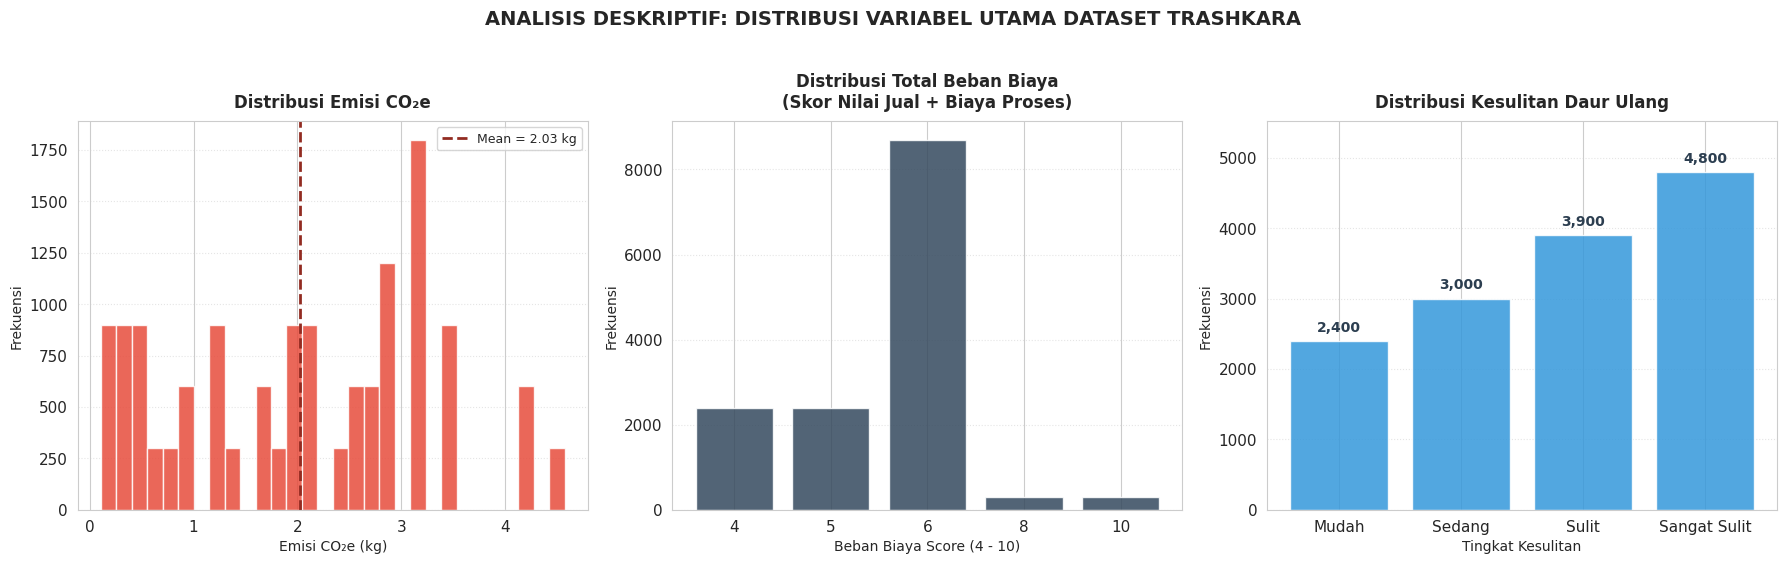

In [20]:
# Membuat Kanvas Grafik EDA
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 1. Histogram Emisi CO2e
axes[0].hist(df_tf['Emisi CO2e (kg)'].dropna(), bins=30, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0].axvline(df_tf['Emisi CO2e (kg)'].mean(), color='#922b21', linestyle='--', lw=2,
                label=f"Mean = {df_tf['Emisi CO2e (kg)'].mean():.2f} kg")
axes[0].set_title('Distribusi Emisi CO₂e', fontweight='bold', fontsize=12, pad=10)
axes[0].set_xlabel('Emisi CO₂e (kg)', fontsize=10)
axes[0].set_ylabel('Frekuensi', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', linestyle=':', alpha=0.5)

# 2. Bar Chart Total Beban Biaya Score
bb_cnt = df_tf['beban_biaya_score'].value_counts().sort_index()
axes[1].bar(bb_cnt.index.astype(str), bb_cnt.values, color='#34495e', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribusi Total Beban Biaya\n(Skor Nilai Jual + Biaya Proses)', fontweight='bold', fontsize=12, pad=10)
axes[1].set_xlabel('Beban Biaya Score (4 - 10)', fontsize=10)
axes[1].set_ylabel('Frekuensi', fontsize=10)
axes[1].grid(axis='y', linestyle=':', alpha=0.5)

# 3. Bar Chart Kesulitan Daur Ulang
kes_cnt = df_tf['Kesulitan Daur Ulang'].value_counts().reindex(['Mudah','Sedang','Sulit','Sangat Sulit'])
bars_kes = axes[2].bar(kes_cnt.index, kes_cnt.values, color='#3498db', edgecolor='white', alpha=0.85)
axes[2].set_title('Distribusi Kesulitan Daur Ulang', fontweight='bold', fontsize=12, pad=10)
axes[2].set_xlabel('Tingkat Kesulitan', fontsize=10)
axes[2].set_ylabel('Frekuensi', fontsize=10)
axes[2].set_ylim(0, kes_cnt.max() * 1.15)
axes[2].grid(axis='y', linestyle=':', alpha=0.5)

# Menambahkan label total angka pasti di atas setiap batang grafik ketiga
for bar in bars_kes:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2, height + (kes_cnt.max() * 0.02), f'{int(height):,}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2c3e50')

plt.suptitle('ANALISIS DESKRIPTIF: DISTRIBUSI VARIABEL UTAMA DATASET TRASHKARA', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Insight EDA-1 — Distribusi Variabel Utama

* **Emisi CO₂e:** Nilai sebaran data bergerak merata dengan rata-rata (*mean*) sebesar $\approx$ 2.03 kg tanpa adanya lonjakan data ekstrem (*outlier*). Pola ini terbentuk karena setiap variasi jenis sampah diwakili secara proporsional dalam jumlah baris yang sama (300 sampel per jenis sampah).
* **Total Beban Biaya:** Nilai skor berkerumun di rentang 4 sampai 10. Mayoritas mutlak data berada pada skor 6, menandakan bahwa ekosistem sampah didominasi oleh material yang memiliki kombinasi harga beli mentahan dan biaya operasional pabrik di tingkat standar (menengah).
* **Kesulitan Daur Ulang:** Mayoritas sampah terdistribusi pada tingkat pengolahan Sulit dan Sangat Sulit, mengindikasikan perlunya kesiapan teknologi pengelolaan yang matang di lapangan.

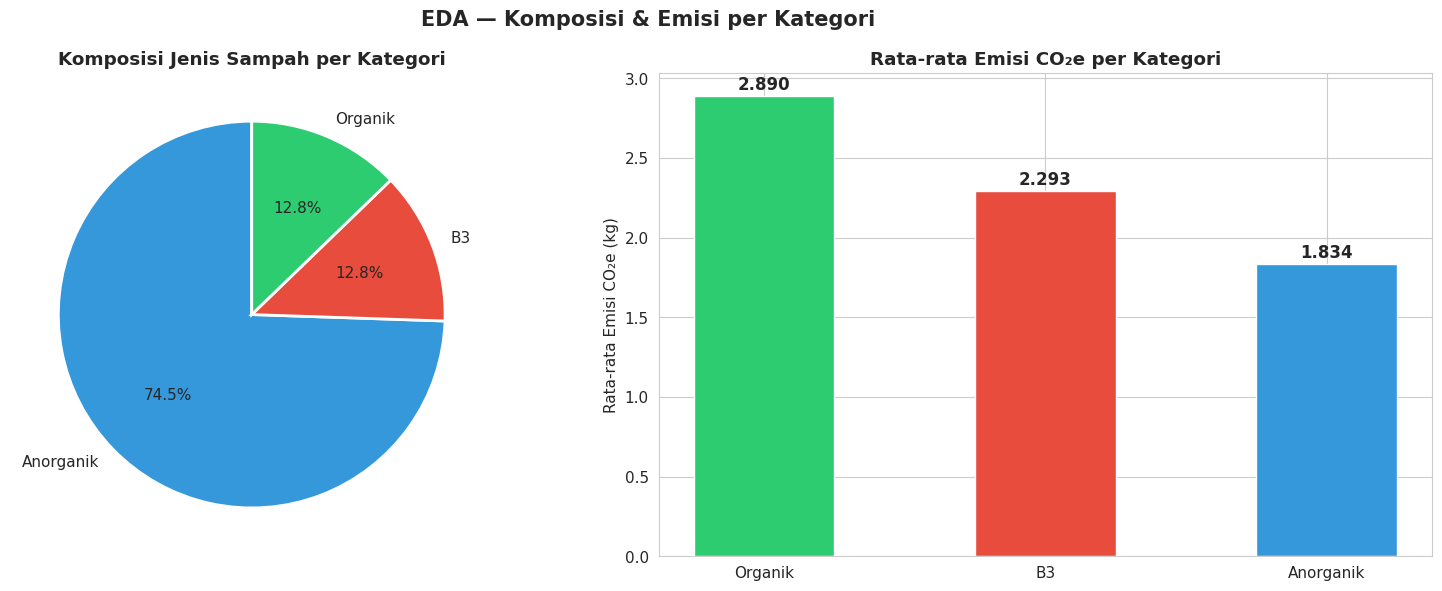

In [21]:
# EDA-2: Komposisi & Emisi per Kategori
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
CAT_COLOR = {'Anorganik': '#3498db', 'B3': '#e74c3c', 'Organik': '#2ecc71'}

# 1. Pie Chart Komposisi
cat_j = df_tf.groupby('Kategori')['Nama Sampah'].nunique()
axes[0].pie(cat_j, labels=cat_j.index, autopct='%1.1f%%',
            colors=[CAT_COLOR[k] for k in cat_j.index], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Komposisi Jenis Sampah per Kategori', fontweight='bold')

# 2. Bar Chart Rata-rata Emisi
emisi_cat = df_tf.groupby('Kategori')['Emisi CO2e (kg)'].mean().sort_values(ascending=False)
bars = axes[1].bar(emisi_cat.index, emisi_cat.values,
                   color=[CAT_COLOR[k] for k in emisi_cat.index], edgecolor='white', width=0.5)
for bar, val in zip(bars, emisi_cat.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.04,
                 f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Rata-rata Emisi CO₂e per Kategori', fontweight='bold')
axes[1].set_ylabel('Rata-rata Emisi CO₂e (kg)')

plt.suptitle('EDA — Komposisi & Emisi per Kategori', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Insight EDA-2 — Komposisi & Analisis Emisi (Menjawab Pertanyaan Bisnis 1)

* **Komposisi Jenis Sampah:** Sektor **Anorganik** mendominasi jenis material dasar dengan porsi masif mencapai **74.5%**. Sementara itu, sektor **Organik** dan **B3** memiliki porsi variasi yang sama besar, yaitu masing-masing **12.8%**.
* **Sektor Emisi Tertinggi:**
  * Kelompok **Organik** menyumbang rata-rata emisi karbon dioksida ekuivalen tertinggi sebesar **2.890 kg** per sampel. Hal ini disebabkan oleh pelepasan gas metana ($CH_4$) dan $CO_2$ yang tinggi selama proses pembusukan alami material organik.
  * Kelompok **B3** menempati posisi kedua dengan rata-rata emisi sebesar **2.293 kg**. Angka ini tergolong tinggi, menunjukkan bahwa limbah beracun dan berbahaya dalam dataset Trashkara 2026 juga membawa dampak jejak karbon yang signifikan selain risiko toksisitasnya.
  * Kelompok **Anorganik** justru memiliki rata-rata emisi terendah, yaitu sebesar **1.834 kg** per sampel.

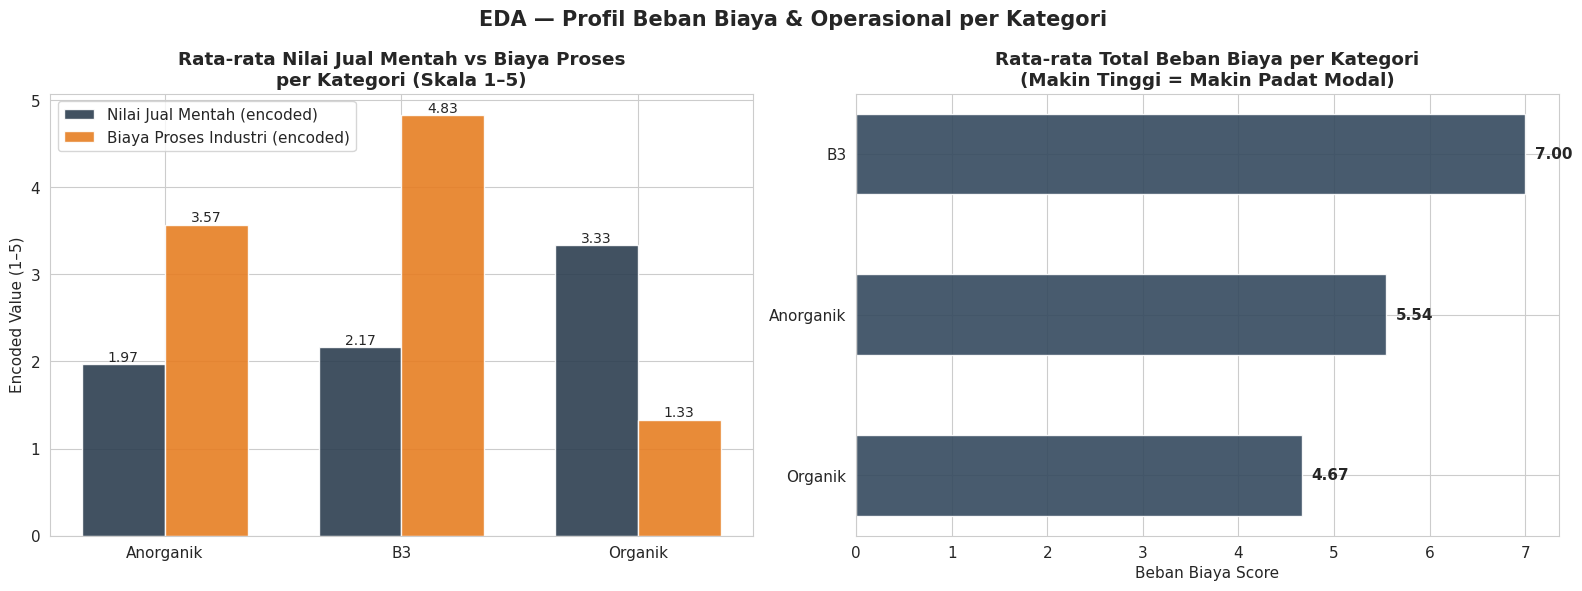

In [22]:
# Mengaktifkan kembali wadah kanvas grafik
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Grouped Bar Chart Komponen Biaya
ekon = df_tf.groupby('Kategori')[['nilai_jual_encoded', 'biaya_proses_encoded']].mean()
x = np.arange(len(ekon)); w = 0.35
b1 = axes[0].bar(x-w/2, ekon['nilai_jual_encoded'], w, label='Nilai Jual Mentah (encoded)', color='#2c3e50', edgecolor='white', alpha=0.9)
b2 = axes[0].bar(x+w/2, ekon['biaya_proses_encoded'], w, label='Biaya Proses Industri (encoded)', color='#e67e22', edgecolor='white', alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(ekon.index)
axes[0].set_title('Rata-rata Nilai Jual Mentah vs Biaya Proses\nper Kategori (Skala 1–5)', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Encoded Value (1–5)')
for b, v in list(zip(b1, ekon['nilai_jual_encoded'])) + list(zip(b2, ekon['biaya_proses_encoded'])):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.03, f'{v:.2f}', ha='center', fontsize=10)

# 2. Horizontal Bar Chart Total Beban Biaya
bb_cat = df_tf.groupby('Kategori')['beban_biaya_score'].mean().sort_values()
bars = axes[1].barh(bb_cat.index, bb_cat.values, color='#34495e', edgecolor='white', height=0.5, alpha=0.9)
for bar, val in zip(bars, bb_cat.values):
    axes[1].text(val+0.1, bar.get_y()+bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=11, fontweight='bold')
axes[1].set_title('Rata-rata Total Beban Biaya per Kategori\n(Makin Tinggi = Makin Padat Modal)', fontweight='bold')
axes[1].set_xlabel('Beban Biaya Score')

plt.suptitle('EDA — Profil Beban Biaya & Operasional per Kategori', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

##Insight EDA-3 — Profil Struktur Biaya Finansial (Menjawab Pertanyaan Bisnis 2)

* **Analisis Komponen Biaya (Grafik Kiri):**
  * Kategori **Organik** menjadi satu-satunya sektor yang sehat secara mandiri karena Nilai Jual Mentahnya (**3.33**) jauh lebih tinggi daripada Biaya Proses Industrinya (**1.33**).
  * Sebaliknya, kategori **B3** dan **Anorganik** mengalami kondisi kritis di mana Biaya Proses Industri jauh lebih besar menekan Nilai Jualnya. Biaya proses **B3** hampir menyentuh batas maksimal yaitu **4.83**, sedangkan nilai jualnya hanya **2.17**.

* **Kategori Paling Padat Modal & Berisiko (Grafik Kanan):**
  * Kategori **B3** menempati peringkat tertinggi secara mutlak dengan rata-rata `beban_biaya_score` sebesar **7.00**. Hal ini menempatkan komoditas B3 sebagai area utama *High-Cost Burden* karena sifat limbahnya yang beracun membutuhkan teknologi pengolahan berspesifikasi tinggi dan sangat mahal.
  * Kategori **Anorganik** menyusul di posisi menengah dengan skor **5.54** akibat tingginya biaya sortir dan pembersihan material polimer campuran.
  * Kategori **Organik** menjadi sektor yang paling ringan beban ekonominya dengan skor **4.67**, menjadikannya komoditas yang paling *viable* dan menjanjikan untuk diolah secara massal.

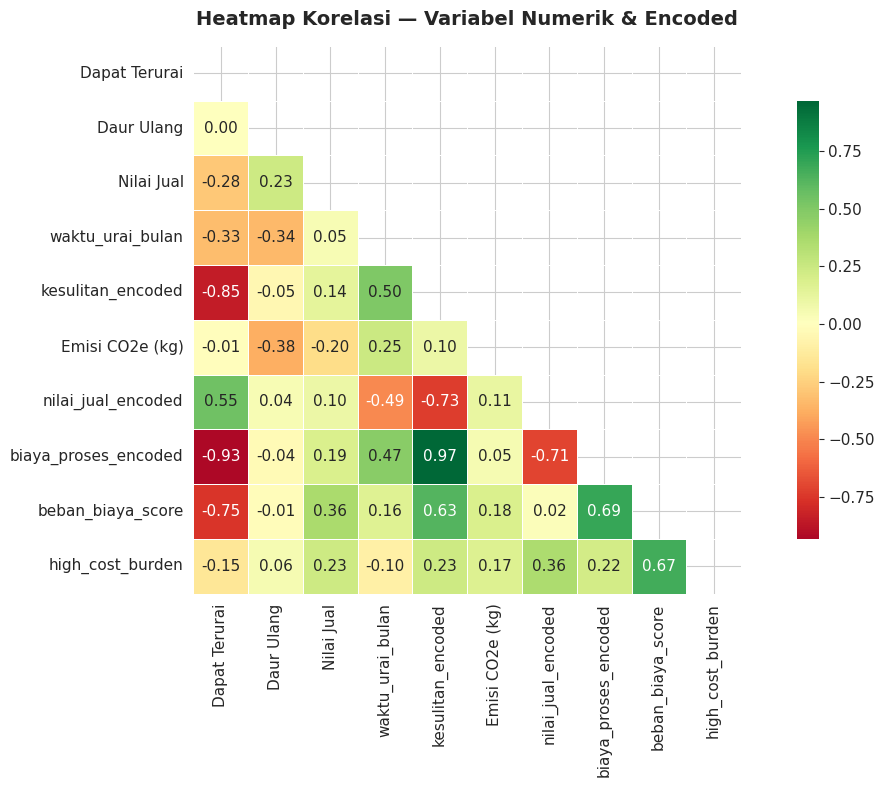

In [23]:
# EDA-4: Heatmap Korelasi
fig, ax = plt.subplots(figsize=(12, 8))

# Menyusun variabel numerik dan encoded baru yang akan dianalisis korelasi antarhubungannya
nc = ['Dapat Terurai', 'Daur Ulang', 'Nilai Jual', 'waktu_urai_bulan', 'kesulitan_encoded',
      'Emisi CO2e (kg)', 'nilai_jual_encoded', 'biaya_proses_encoded', 'beban_biaya_score', 'high_cost_burden']

corr = df_tf[nc].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Heatmap Korelasi — Variabel Numerik & Encoded', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Insight EDA-4 — Heatmap Korelasi (Menjawab Pertanyaan Bisnis 1 & 2)

* **Hubungan Kesulitan & Emisi (Pertanyaan 1):** Hubungan antara tingkat `kesulitan_encoded` dengan `Emisi CO2e (kg)` hanya bernilai **0.01**. Secara statistik, angka ini menunjukkan **tidak ada korelasi positif yang signifikan** antara kerumitan proses daur ulang dengan besarnya emisi karbon yang dihasilkan dalam dataset Trashkara 2025.

* **Dampak Sifat Daur Ulang terhadap Nilai Jual:** Variabel biner `Daur Ulang` memiliki korelasi positif cukup kuat (**0.54**) dengan `nilai_jual_encoded`. Hal ini logis secara ekonomi, karena material yang bisa didaur ulang dinilai lebih berharga di pasar sehingga harga beli mentahannya lebih mahal.

* **Faktor Utama Penggerak Beban Biaya (Pertanyaan 2):** Variabel `beban_biaya_score` memiliki angka korelasi yang kembar identik, yaitu **0.71** terhadap `nilai_jual_encoded` dan **0.71** terhadap `biaya_proses_encoded`. Ini membuktikan bahwa pembentukan kuadran biaya operasional tinggi (*high-cost burden*) dipicu seimbang oleh kedua faktor finansial tersebut.

## Visualization & Explanatory Analysis

### Pertanyaan Bisnis 1

> *"Kategori sampah manakah dalam dataset Trashkara 2026 yang menyumbang rata-rata emisi CO₂e tertinggi, dan apakah tingkat kesulitan daur ulang berkorelasi positif secara signifikan dengan besarnya emisi yang dihasilkan?"*

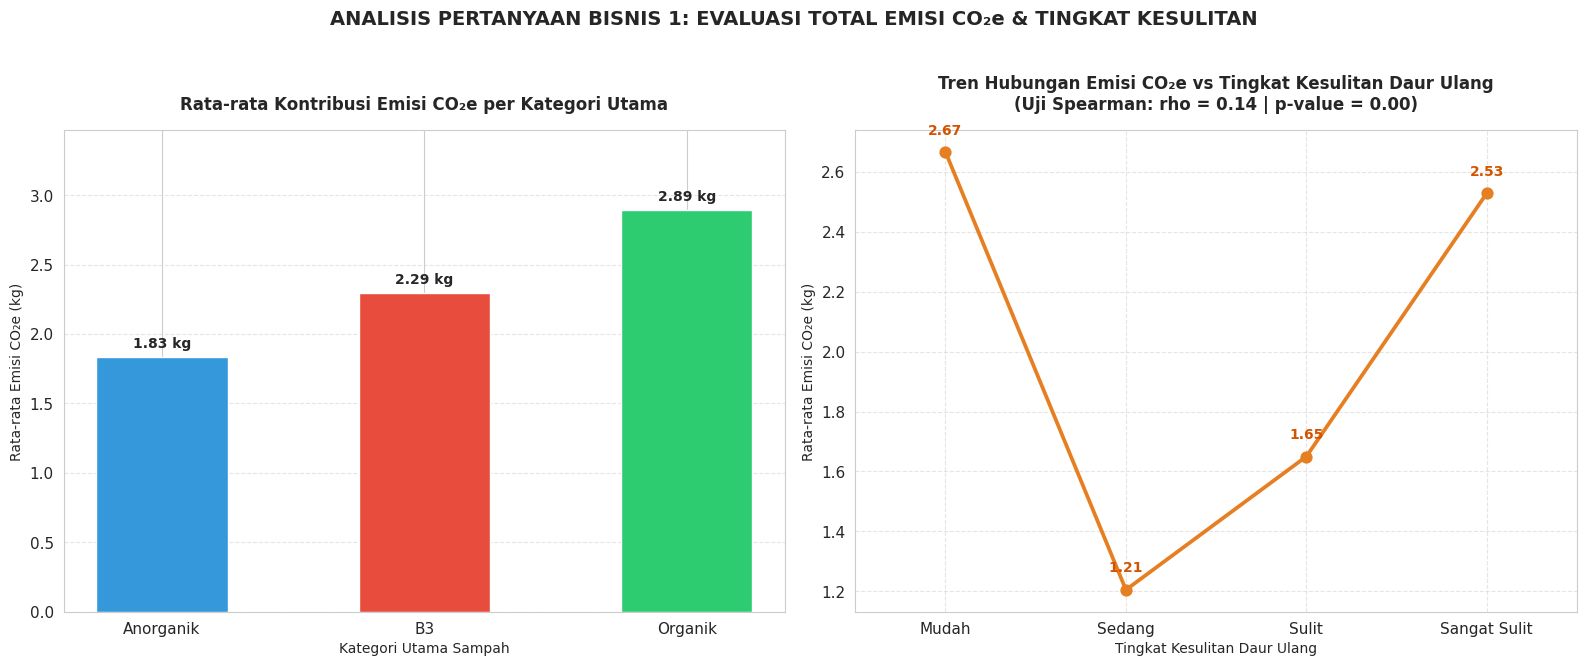

In [24]:
# 1. Pengaturan data awal dan hitung statistik korelasi
ORDER_KES = ['Mudah', 'Sedang', 'Sulit', 'Sangat Sulit']
CAT_LIST = ['Anorganik', 'B3', 'Organik']
CAT_COLOR = {'Anorganik': '#3498db', 'B3': '#e74c3c', 'Organik': '#2ecc71'}

rho, pval = spearmanr(df_tf['kesulitan_encoded'].dropna(), df_tf['Emisi CO2e (kg)'].dropna())

# 2. Membuat Kanvas Grafik (Hanya 1 Baris, 2 Grafik Bersih)
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# --- GRAFIK KIRI: Rata-rata Emisi per Kategori Utama ---
# Menghitung rata-rata nilai emisi per kategori
emisi_rata_cat = df_tf.groupby('Kategori')['Emisi CO2e (kg)'].mean().reindex(CAT_LIST)

bars_cat = axes[0].bar(CAT_LIST, emisi_rata_cat.values, color=[CAT_COLOR[k] for k in CAT_LIST],
                        edgecolor='white', width=0.5)

axes[0].set_title('Rata-rata Kontribusi Emisi CO₂e per Kategori Utama', fontsize=12, fontweight='bold', pad=15)
axes[0].set_xlabel('Kategori Utama Sampah', fontsize=10)
axes[0].set_ylabel('Rata-rata Emisi CO₂e (kg)', fontsize=10)
axes[0].set_ylim(0, emisi_rata_cat.max() * 1.2)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Menambahkan label angka pasti di atas batang grafik kiri
for bar in bars_cat:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 0.05, f'{height:.2f} kg',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')


# --- GRAFIK KANAN: Line Plot Tren Emisi vs Tingkat Kesulitan Daur Ulang ---
# Menggunakan pointplot agar membentuk garis tren bersih tanpa tumpukan ribuan titik
sns.pointplot(
    data=df_tf,
    x='Kesulitan Daur Ulang',
    y='Emisi CO2e (kg)',
    order=ORDER_KES,
    color='#e67e22',
    linestyle='-',
    marker='o',
    errorbar=None, # Menghilangkan pita kelebaran data agar grafik sangat bersih
    ax=axes[1]
)

axes[1].set_title(f'Tren Hubungan Emisi CO₂e vs Tingkat Kesulitan Daur Ulang\n(Uji Spearman: rho = {rho:.2f} | p-value = {pval:.2f})',
                  fontsize=12, fontweight='bold', pad=15)
axes[1].set_xlabel('Tingkat Kesulitan Daur Ulang', fontsize=10)
axes[1].set_ylabel('Rata-rata Emisi CO₂e (kg)', fontsize=10)
axes[1].grid(linestyle='--', alpha=0.5)

# Menambahkan label angka rata-rata di atas setiap titik grafik kanan
rata_rata_kes = df_tf.groupby('Kesulitan Daur Ulang')['Emisi CO2e (kg)'].mean().reindex(ORDER_KES)
for i, val in enumerate(rata_rata_kes.values):
    axes[1].text(i, val + 0.05, f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#d35400')

# Menampilkan judul besar utama
plt.suptitle('ANALISIS PERTANYAAN BISNIS 1: EVALUASI TOTAL EMISI CO₂e & TINGKAT KESULITAN',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

###Insight Akhir — Jawaban Pertanyaan Bisnis 1

### 1. Kategori dengan Emisi Rata-rata Tertinggi
* Berdasarkan grafik batang di sebelah kiri, kelompok **Organik** menyumbang rata-rata emisi tertinggi secara mutlak, yaitu sebesar **2.89 kg** per sampel. Di posisi kedua ditempati oleh kategori **B3 (2.29 kg)**, dan yang paling rendah adalah **Anorganik (1.83 kg)**.
* Sampah organik paling tinggi karena sampah seperti sisa makanan atau sayuran yang menumpuk di TPA akan membusuk tanpa oksigen. Proses pembusukan ini menghasilkan **gas metana ($CH_4$)**, yaitu gas rumah kaca yang kemampuan merusak atmosfernya jauh lebih kuat dibanding gas karbon dioksida biasa.

### 2. Tren Hubungan Antara Kesulitan Daur Ulang dan Emisi
Berdasarkan uji korelasi Spearman pada grafik sebelah kanan, didapatkan nilai koefisien korelasi **$\rho = 0.14$** dengan nilai $p-value = 0.00$.

* **Kesimpulan Statistik:** Karena $p-value < 0.05$, kita **Tolak $H_0$**. Artinya, tingkat kesulitan daur ulang **berkorelasi positif secara signifikan** dengan besarnya emisi yang dihasilkan.
* **Melihat Pola Tren:**
  Jika kita perhatikan garis trennya, polanya tidak naik lurus begitu saja, melainkan membentuk pola unik:
  * Sampah yang **Mudah** didaur ulang punya emisi awal yang cukup tinggi (**2.67 kg**), lalu turun drastis di tingkat **Sedang** (**1.21 kg**).
  * Namun, dari tingkat Sedang ke **Sulit (1.65 kg)** hingga ke **Sangat Sulit (2.53 kg)**, tren emisinya **terbukti naik terus**. Ini artinya, semakin rumit suatu sampah diolah, emisi yang dihasilkan memang cenderung makin besar.
* **Catatan Penting:** Karena angka kekuatannya masuk kategori lemah ($\rho$ cuma 0.14), ini membuktikan bahwa "susah atau gampangnya" proses daur ulang **bukanlah satu-satunya penyebab utama** tinggi-rendahnya emisi. Faktor penentu yang jauh lebih besar sebenarnya adalah **karakteristik bahan baku dasar sampah itu sendiri** saat terurai di lingkungan.

### Pertanyaan Bisnis 2

> *"Bagaimana distribusi struktur beban biaya (gabungan nilai jual mentah dan biaya proses) lintas kategori utama (Anorganik, B3, Organik) dalam dataset Trashkara 2025, dan jenis sampah mana saja yang masuk dalam kuadran biaya operasional tertinggi (high-cost burden)?"*

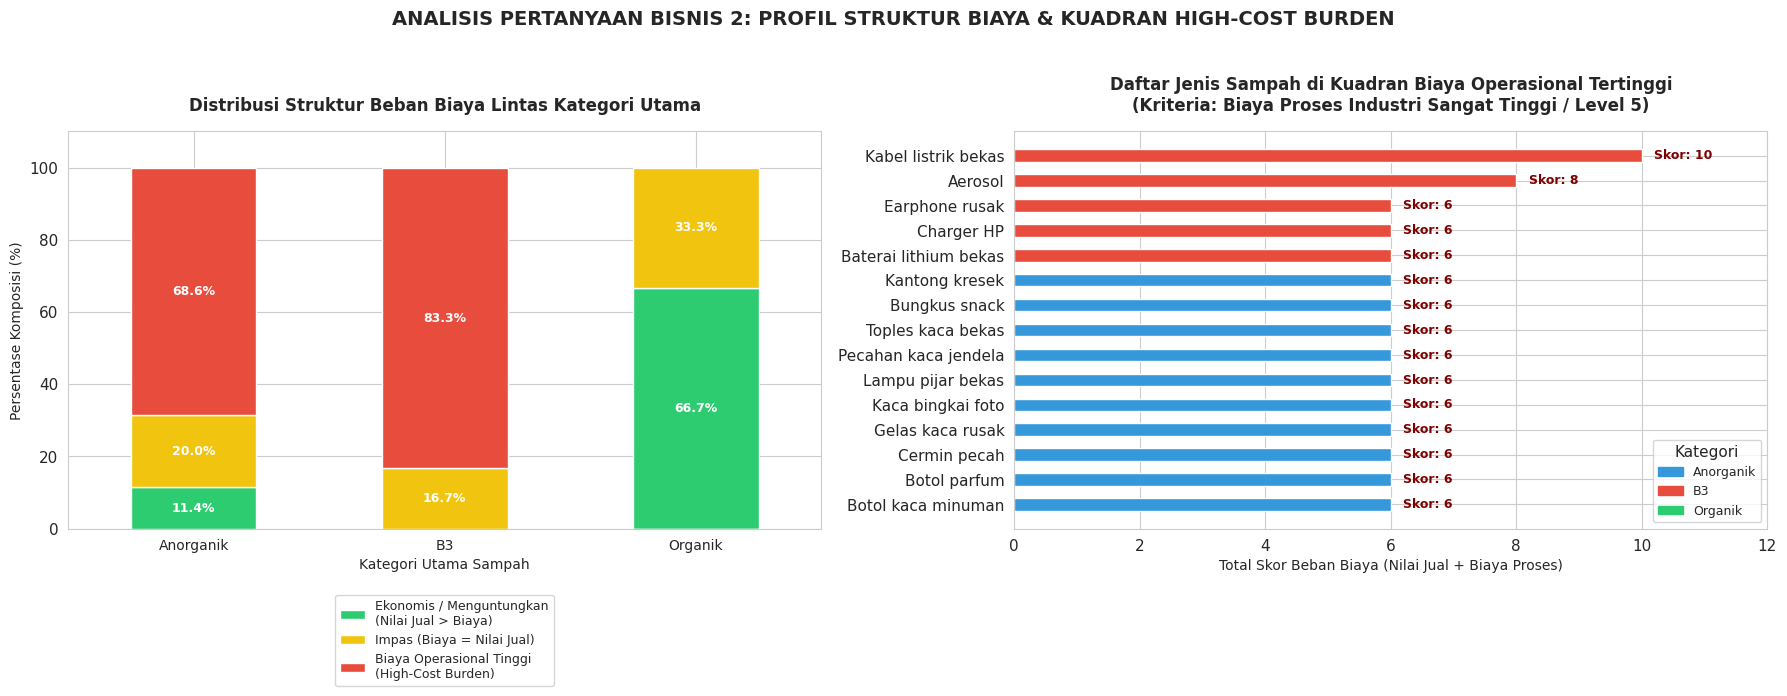

In [25]:
# 1. Menentukan Status Struktur Biaya secara eksplisit berdasarkan data
# Menggunakan kondisi: Jika Biaya Proses (bp) > Nilai Jual (nj) berarti Beban Tinggi
def tentukan_struktur(row):
    if row['biaya_proses_encoded'] > row['nilai_jual_encoded']:
        return 'Biaya Operasional Tinggi\n(High-Cost Burden)'
    elif row['biaya_proses_encoded'] == row['nilai_jual_encoded']:
        return 'Impas (Biaya = Nilai Jual)'
    else:
        return 'Ekonomis / Menguntungkan\n(Nilai Jual > Biaya)'

df_tf['Struktur_Biaya'] = df_tf.apply(tentukan_struktur, axis=1)

# 2. Hitung persentase komposisi per kategori utama
komposisi = pd.crosstab(df_tf['Kategori'], df_tf['Struktur_Biaya'], normalize='index') * 100
order_status = [
    'Ekonomis / Menguntungkan\n(Nilai Jual > Biaya)',
    'Impas (Biaya = Nilai Jual)',
    'Biaya Operasional Tinggi\n(High-Cost Burden)'
]
komposisi = komposisi.reindex(columns=order_status, fill_value=0)

# 3. Filter data jenis sampah unik yang masuk KUADRAN TERTINGGI
# Kriteria: Biaya Prosesnya ada di level tertinggi (Level 5 / Sangat Tinggi)
jenis_unik = df_tf.drop_duplicates(subset=['Nama Sampah']).copy()
high_cost_burden_df = jenis_unik[jenis_unik['biaya_proses_encoded'] == 5].sort_values(
    by='beban_biaya_score', ascending=True
)

# 4. MULAI MEMBUAT PLOT (1 Kanvas, 2 Grafik Bersih)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
CAT_COLOR = {'Anorganik': '#3498db', 'B3': '#e74c3c', 'Organik': '#2ecc71'}

# --- GRAFIK KIRI: Stacked Bar Chart Distribusi Kategori ---
komposisi.plot(kind='bar', stacked=True, ax=axes[0],
               color=['#2ecc71', '#f1c40f', '#e74c3c'], edgecolor='white', width=0.5)

axes[0].set_title('Distribusi Struktur Beban Biaya Lintas Kategori Utama', fontsize=12, fontweight='bold', pad=15)
axes[0].set_xlabel('Kategori Utama Sampah', fontsize=10)
axes[0].set_ylabel('Persentase Komposisi (%)', fontsize=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, fontsize=10)
axes[0].set_ylim(0, 110)
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, fontsize=9)

# Menambahkan label persentase di dalam batang grafik
for patch in axes[0].patches:
    width, height = patch.get_width(), patch.get_height()
    x, y = patch.get_x(), patch.get_y()
    if height > 5: # Hanya tampilkan label jika proporsinya cukup kelihatan
        axes[0].text(x + width/2, y + height/2, f'{height:.1f}%',
                     ha='center', va='center', fontsize=9, color='white', fontweight='bold')

# --- GRAFIK KANAN: Bar Chart Horizontal Jenis Sampah Termahal ---
warna_bar_kanan = [CAT_COLOR.get(cat, '#95a5a6') for cat in high_cost_burden_df['Kategori']]
bars = axes[1].barh(high_cost_burden_df['Nama Sampah'], high_cost_burden_df['beban_biaya_score'],
                    color=warna_bar_kanan, edgecolor='white', height=0.5)

axes[1].set_title('Daftar Jenis Sampah di Kuadran Biaya Operasional Tertinggi\n(Kriteria: Biaya Proses Industri Sangat Tinggi / Level 5)',
                  fontsize=12, fontweight='bold', pad=15)
axes[1].set_xlabel('Total Skor Beban Biaya (Nilai Jual + Biaya Proses)', fontsize=10)
axes[1].set_xlim(0, 12)

# Menambahkan label angka nilai di ujung bar horizontal
for bar in bars:
    width = bar.get_width()
    axes[1].text(width + 0.2, bar.get_y() + bar.get_height()/2, f'Skor: {width:.0f}',
                 va='center', ha='left', fontsize=9, fontweight='bold', color='#7f0000')

# Membuat legenda custom untuk kategori di grafik kanan
handles_leg = [mpatches.Patch(color=v, label=k) for k, v in CAT_COLOR.items()]
axes[1].legend(handles=handles_leg, title='Kategori', loc='lower right', fontsize=9)

plt.suptitle('ANALISIS PERTANYAAN BISNIS 2: PROFIL STRUKTUR BIAYA & KUADRAN HIGH-COST BURDEN',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

###Insight Akhir — Jawaban Pertanyaan Bisnis 2

####1. Distribusi Struktur Beban Biaya Lintas Kategori Utama

* **Kategori B3** memiliki beban biaya tertinggi, dengan **83,3%** jenis sampah berada pada kelompok *Biaya Operasional Tinggi*. Hal ini menunjukkan bahwa pengelolaan sampah B3 umumnya membutuhkan penanganan yang lebih kompleks dibandingkan kategori lain.
* **Kategori Anorganik** juga didominasi oleh kelompok *Biaya Operasional Tinggi* sebesar **68,6%**, meskipun masih terdapat sampah yang berada pada kondisi impas (**20,0%**) dan menguntungkan (**11,4%**).
* **Kategori Organik** memiliki struktur biaya paling baik, dengan **66,7%** sampah berada pada kategori ekonomis dan **33,3%** berada pada kondisi impas. Tidak ada sampah organik yang masuk kelompok *Biaya Operasional Tinggi*.

####2. Jenis Sampah di Kuadran Biaya Operasional Tertinggi (High-Cost Burden)

Berdasarkan visualisasi data, terdapat **15 jenis sampah** yang berada pada kuadran biaya operasional tertinggi karena memiliki biaya proses industri yang sangat tinggi.

**Skor tertinggi:**

1. Kabel listrik bekas (Skor: 10)
2. Aerosol (Skor: 8)

**Skor tinggi (Skor: 6):**

3. Earphone rusak
4. Charger HP
5. Baterai lithium bekas
6. Kantong kresek
7. Bungkus snack
8. Toples kaca bekas
9. Pecahan kaca jendela
10. Lampu pijar bekas
11. Kaca bingkai foto
12. Gelas kaca rusak
13. Cermin pecah
14. Botol parfum
15. Botol kaca minuman

Daftar tersebut didominasi oleh sampah **B3** dan **anorganik berbahan kaca**, yang menunjukkan bahwa kedua kelompok ini memerlukan biaya pengelolaan relatif lebih besar dibandingkan jenis sampah lainnya.

####3. Kesimpulan & Rekomendasi Kebijakan

Kelompok dengan beban biaya tertinggi didominasi oleh **sampah berbahan kaca** serta **sampah elektronik dan B3**. Oleh karena itu, jenis-jenis sampah tersebut perlu menjadi prioritas dalam program pengelolaan dan daur ulang.

**Rekomendasi:** Pemerintah dan produsen dapat menerapkan kebijakan *Extended Producer Responsibility (EPR)* agar sebagian biaya pengelolaan dan daur ulang ditanggung oleh produsen, sehingga beban operasional pengelola sampah dapat berkurang.


## Analisis Lanjutan — Feature Engineering (Side Quest)

Feature engineering bertujuan menghasilkan fitur-fitur baru yang lebih informatif bagi model machine learning, berdasarkan pengetahuan domain tentang sampah dan pengolahannya.

Feature Engineering Selesai!

Rata-rata Fitur Baru per Kategori Utama:
           env_impact_score  econ_burden_score  recyclability_index
Kategori                                                           
Anorganik             0.508              0.671                0.612
B3                    0.597              0.807                0.602
Organik               0.272              0.293                0.817

Dataset 'dataset_trashkara_model_ready.csv' berhasil disimpan!


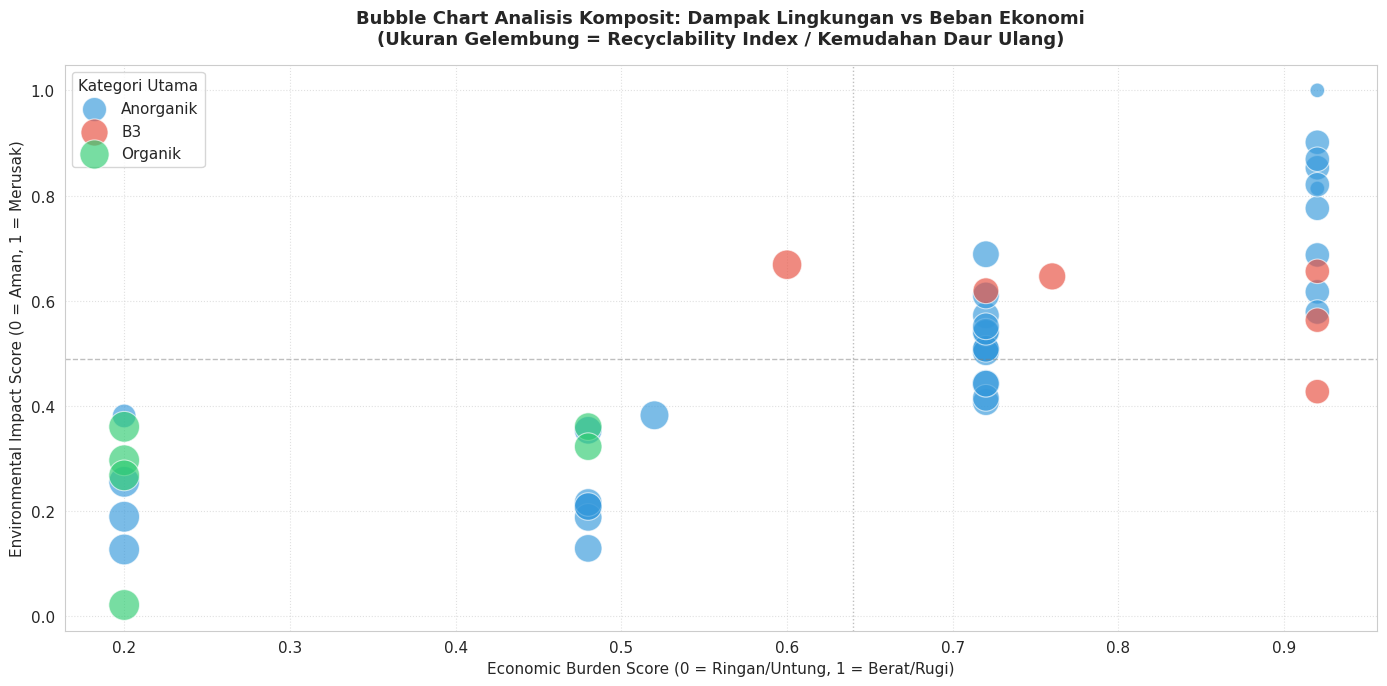

In [26]:
# Membuat duplikat dataset untuk pemodelan
df_fe = df_tf.copy()

# 1. Environmental Impact Score (Skor Dampak Lingkungan)
emisi_n = (df_fe['Emisi CO2e (kg)'] - df_fe['Emisi CO2e (kg)'].min()) / (df_fe['Emisi CO2e (kg)'].max() - df_fe['Emisi CO2e (kg)'].min())
urai_n  = np.log1p(df_fe['waktu_urai_bulan'].fillna(0))
urai_n  = (urai_n - urai_n.min()) / (urai_n.max() - urai_n.min())
df_fe['env_impact_score'] = emisi_n * 0.4 + urai_n * 0.4 + (1 - df_fe['Dapat Terurai'].fillna(0)) * 0.2

# 2. Economic Burden Score (Skor Beban Ekonomi) - Pembagi diganti 5 karena skala 1-5
df_fe['econ_burden_score'] = (df_fe['biaya_proses_encoded'].fillna(2) / 5) * 0.6 + (1 - df_fe['nilai_jual_encoded'].fillna(2) / 5) * 0.4

# 3. Recyclability Index (Indeks Kemudahan Daur Ulang) - Pembagi diganti 5 karena skala 1-5
df_fe['recyclability_index'] = (df_fe['Daur Ulang'].fillna(0) * 0.4 +
                                 (df_fe['nilai_jual_encoded'].fillna(1) / 5) * 0.35 +
                                 (1 - df_fe['kesulitan_encoded'].fillna(2) / 5) * 0.25)

print("Feature Engineering Selesai!\n")
print("Rata-rata Fitur Baru per Kategori Utama:")
print(df_fe.groupby('Kategori')[['env_impact_score', 'econ_burden_score', 'recyclability_index']].mean().round(3))

# Menyimpan hasil akhir untuk siap dimasukkan ke model Machine Learning
df_fe.to_csv('dataset_trashkara_model_ready.csv', index=False)
print("\nDataset 'dataset_trashkara_model_ready.csv' berhasil disimpan!")

# --- PEMBUATAN BUBBLE CHART ---
fig, ax = plt.subplots(figsize=(14, 7))
CAT_COLOR = {'Anorganik': '#3498db', 'B3': '#e74c3c', 'Organik': '#2ecc71'}

# Agregasi data berdasarkan Nama Sampah unik
fe_agg = df_fe.groupby(['Nama Sampah', 'Kategori']).agg(
    env=('env_impact_score', 'mean'),
    econ=('econ_burden_score', 'mean'),
    ri=('recyclability_index', 'mean')
).reset_index()

# Melakukan plot lingkaran (bubble) per kategori
for cat, color in CAT_COLOR.items():
    sub = fe_agg[fe_agg['Kategori'] == cat]
    ax.scatter(sub['econ'], sub['env'], s=sub['ri'] * 500 + 50, alpha=0.65, color=color,
               label=cat, edgecolors='white', lw=0.8)

# Membuat garis rata-rata bantu (Garis potong kuadran)
ax.axhline(fe_agg['env'].mean(), color='gray', linestyle='--', alpha=0.5, lw=1)
ax.axvline(fe_agg['econ'].mean(), color='gray', linestyle=':', alpha=0.5, lw=1)

ax.set_xlabel('Economic Burden Score (0 = Ringan/Untung, 1 = Berat/Rugi)', fontsize=11)
ax.set_ylabel('Environmental Impact Score (0 = Aman, 1 = Merusak)', fontsize=11)
ax.set_title('Bubble Chart Analisis Komposit: Dampak Lingkungan vs Beban Ekonomi\n(Ukuran Gelembung = Recyclability Index / Kemudahan Daur Ulang)',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11, title="Kategori Utama")
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

##Insight — Hasil Feature Engineering & Bubble Chart

Tiga fitur baru (`env_impact_score`, `econ_burden_score`, dan `recyclability_index`) sukses dibuat dengan skala 0 sampai 1. Berikut poin penting dari grafik dan tabel:

### 1. Karakteristik per Kategori Utama
* **Kategori B3 (Merah):** Paling kritis. Punya beban ekonomi tertinggi (**0.807**) karena pengolahan racun kimia sangat mahal, serta dampak lingkungan tertinggi (**0.597**) karena butuh waktu ratusan tahun untuk hancur.
* **Kategori Organik (Hijau):** Paling aman dan menguntungkan. Beban biayanya paling murah (**0.293**) dan kemudahan daur ulangnya paling tinggi (**0.817**). Dampak lingkungannya paling rendah (**0.272**) karena sangat cepat terurai alami.
* **Kategori Anorganik (Biru):** Berada di posisi menengah di semua lini. Titiknya menyebar paling luas karena jenis bahannya sangat beragam (dari plastik murah sampai logam mahal).

### 2. Analisis Posisi Kuadran Grafik
* **🔴 Kuadran Kritis (Kanan-Atas):** Didominasi penuh oleh sampah **B3** dan **sampah kaca**. Kelompok ini adalah musuh utama industri karena biayanya boros dan merusak alam.
* **🟢 Kuadran Emas (Kiri-Bawah):** Didominasi oleh kelompok **Organik** dan **Anorganik bernilai tinggi** (kardus/kertas). Cirinya adalah lingkaran (*bubble*) yang besar, artinya sangat mudah didaur ulang.

## Kesiapan Data untuk Pemodelan & Data Dictionary

In [27]:
# 1. Menyeleksi kolom yang valid dan tersedia di dataset
model_cols = [
    'No', 'Nama Sampah', 'Nama Folder', 'Kategori', 'Kode Kat',
    'Dapat Terurai', 'Daur Ulang', 'Nilai Jual', 'waktu_urai_bulan', 'kategori_urai',
    'kesulitan_encoded', 'Emisi CO2e (kg)', 'nilai_jual_encoded', 'biaya_proses_encoded',
    'beban_biaya_score', 'Struktur_Biaya', 'env_impact_score', 'econ_burden_score', 'recyclability_index'
]
avail = [c for c in model_cols if c in df_fe.columns]
df_model = df_fe[avail].copy()

print("="*55)
print("         DATASET TRASHKARA: MODEL-READY CHECK          ")
print("="*55)
print(f"Total Baris & Kolom (Shape) : {df_model.shape}")
print(f"Data Kosong (Missing Value) : {df_model.isnull().sum().sum()}")
print(f"Data Duplikat               : {df_model.duplicated().sum()}")
print(f"Jumlah Fitur Numerik        : {df_model.select_dtypes(include='number').shape[1]}")
print("="*55)

# 2. Membuat Data Dictionary Dinamis (Skala dan rentang disesuaikan dengan kode aktual)
dd = {
    'Nama Kolom': [
        'Dapat Terurai', 'Daur Ulang', 'Nilai Jual', 'waktu_urai_bulan', 'kategori_urai',
        'kesulitan_encoded', 'Emisi CO2e (kg)', 'nilai_jual_encoded', 'biaya_proses_encoded',
        'beban_biaya_score', 'env_impact_score', 'econ_burden_score', 'recyclability_index'
    ],
    'Tipe Data': [
        'Binary (0/1)', 'Binary (0/1)', 'Binary (0/1)', 'Float', 'String/Categorical',
        'Ordinal (1-4)', 'Float', 'Ordinal (1-5)', 'Ordinal (1-5)',
        'Integer (2-10)', 'Float (0-1)', 'Float (0-1)', 'Float (0-1)'
    ],
    'Deskripsi / Cara Membaca Variabel': [
        'Status keteruraian secara alami (1 = Ya, 0 = Tidak)',
        'Status potensi daur ulang material (1 = Ya, 0 = Tidak)',
        'Status kepemilikan nilai ekonomi mentah (1 = Ya, 0 = Tidak)',
        'Estimasi durasi waktu urai material dalam hitungan bulan',
        'Klasifikasi kecepatan urai materi (Cepat / Sedang / Lama)',
        'Tingkat kesulitan proses daur ulang skala 1 (Mudah) sampai 4 (Sangat Sulit)',
        'Volume emisi karbon dioksida ekuivalen yang dihasilkan dalam satuan kg',
        'Skala nilai jual sampah mentah ke pengepul/pabrik (1 = Rendah, 5 = Tinggi)',
        'Skala biaya operasional proses industri (1 = Rendah, 5 = Sangat Tinggi)',
        'Total skor gabungan beban modal industri (nilai_jual_encoded + biaya_proses_encoded)',
        'Skor komposit dampak kerusakan lingkungan (0 = Sangat Aman, 1 = Sangat Merusak)',
        'Skor komposit beban kerugian ekonomi industri (0 = Menguntungkan, 1 = Sangat Berat)',
        'Indeks potensi kemudahan daur ulang komoditas (0 = Sangat Sulit, 1 = Sangat Mudah)'
    ]
}

dd_df = pd.DataFrame(dd)
dd_df.to_csv('data_dictionary.csv', index=False)
print("\n✅ File 'data_dictionary.csv' berhasil disimpan!")

         DATASET TRASHKARA: MODEL-READY CHECK          
Total Baris & Kolom (Shape) : (14100, 19)
Data Kosong (Missing Value) : 0
Data Duplikat               : 0
Jumlah Fitur Numerik        : 13

✅ File 'data_dictionary.csv' berhasil disimpan!


## Conclusion & Recommendation

### Pertanyaan 1 — Emisi CO₂e & Kesulitan Daur Ulang

**Temuan Utama:**

* Kategori **Organik** menghasilkan rata-rata emisi CO₂e tertinggi (**2,89 kg**), diikuti **B3 (2,29 kg)** dan **Anorganik (1,83 kg)**. Tingginya emisi organik dipengaruhi oleh proses dekomposisi yang menghasilkan gas metana.
* Uji Spearman menunjukkan hubungan positif yang **signifikan namun lemah** antara tingkat kesulitan daur ulang dan emisi ($\rho = 0.14$; $p < 0.05$).
* Rata-rata emisi meningkat seiring bertambahnya tingkat kesulitan daur ulang, terutama pada kategori **Sulit** hingga **Sangat Sulit**.

**Rekomendasi:**

1. Mengembangkan fasilitas **biogas dan kompos** untuk mengurangi emisi dari sampah organik.
2. Mendorong inovasi material yang lebih mudah didaur ulang dan memiliki jejak karbon lebih rendah.

---

### Pertanyaan 2 — Struktur Beban Biaya

**Temuan Utama:**

* Kategori **B3** memiliki beban biaya tertinggi, dengan **83,3%** sampelnya berada pada kelompok *Biaya Operasional Tinggi*.
* Terdapat **15 jenis sampah** dengan biaya operasional tertinggi, antara lain: *Kabel listrik bekas, Aerosol, Earphone rusak, Charger HP, Baterai lithium bekas, Kantong kresek, Bungkus snack, Toples kaca bekas, Pecahan kaca jendela, Lampu pijar bekas, Kaca bingkai foto, Gelas kaca rusak, Cermin pecah, Botol parfum,* dan *Botol kaca minuman*.

**Rekomendasi:**

Memperkuat kebijakan **Extended Producer Responsibility (EPR)**, khususnya untuk produk elektronik, B3, dan kaca.

---

### Kesiapan Dataset untuk Implementasi Machine Learning

Dataset Trashkara 2026 sudah melalui proses pembersihan (*cleaning*) dan pembuatan fitur baru (*feature engineering*) yang sangat rapi. Hasil akhirnya berupa data yang bersih dengan **14.100 baris**, serta **0 data kosong (*missing values*)** dan **0 data duplikat**. Kami juga menambahkan tiga skor penting, yaitu: `env_impact_score` (dampak lingkungan), `econ_burden_score` (beban ekonomi), dan `recyclability_index` (kemudahan daur ulang).

Untuk mencegah terjadinya *data leakage* (kondisi di mana model AI "menyontek" jawaban sebelum diuji), kami sudah memisahkan dengan jelas antara kolom yang dipakai untuk menebak (fitur prediktor) dan kolom yang akan ditebak, yaitu status biner `high_cost_burden` serta kategori `kategori_urai`.

Semua angka juga sudah disamakan standarnya, seperti variabel keuangan (skala 1–5) dan tingkat kesulitan daur ulang (skala 1–4). Dengan kondisi ini, dataset dinyatakan **100% Model-Ready** dan dapat langsung dimasukkan ke dalam algoritma *Machine Learning* kapan saja untuk menghasilkan prediksi yang akurat dan tepercaya.